# **LangChain Multi-modal RAG 구현 (Docling 파서 기반)**

- **학습 목표**:
  - 멀티모달 RAG (텍스트 요약 기반 RAG)의 핵심 아키텍처 및 워크플로우 이해
  - **Docling**을 활용하여 금융/IR 리포트 PDF에서 표, 이미지, 텍스트를 구조화하여 추출
  - 멀티모달 LLM(GPT-4.1 / GPT-4.1-mini)으로 표/이미지 요약을 생성하고 `MultiVectorRetriever`로 원본 객체와 매핑
  - 파싱 해상도(`images_scale`)에 따른 표/이미지 구조 인식 품질 비교

---

### 1. **환경 변수 로드 (`.env`)**

In [ ]:
from dotenv import load_dotenv
load_dotenv()

### 2. **기본 라이브러리 임포트**

In [ ]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

### 3. **Langfuse 모니터링 핸들러 설정**

In [ ]:
from langfuse.langchain import CallbackHandler
import os

# Langfuse v4 CallbackHandler 초기화
# .env 파일에 LANGFUSE_PUBLIC_KEY, LANGFUSE_SECRET_KEY, LANGFUSE_HOST 가 설정되어 있으면 자동 활성화
try:
    if os.getenv("LANGFUSE_PUBLIC_KEY") and os.getenv("LANGFUSE_SECRET_KEY"):
        langfuse_handler = CallbackHandler()
        print("✅ Langfuse CallbackHandler 초기화 완료 (트레이싱 활성화)")
    else:
        langfuse_handler = None
        print("ℹ️ Langfuse 키 미설정 — 로컬 모드로 동작 (Graceful fallback)")
except Exception as e:
    langfuse_handler = None
    print(f"⚠️ Langfuse 초기화 실패: {e}")


### 4. **공통 유틸리티 함수 정의**

In [ ]:
import base64
import io
from io import BytesIO

import numpy as np
from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document

import pickle
from langchain_core.stores import InMemoryStore


def is_base64(s):
    """문자열이 Base64로 인코딩되었는지 확인합니다"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False


def split_image_text_types(docs):
    """numpy 배열 이미지와 텍스트를 분리합니다"""
    images = []
    text = []
    for doc in docs:
        if isinstance(doc, str):
            pass
        elif isinstance(doc, Document):
            doc = doc.page_content  # 문서 내용 추출
        else:
            doc = doc.text # 문서 내용 추출

        if is_base64(doc):
            images.append(doc)  # base64로 인코딩된 문자열
        else:
            text.append(doc)
    return {"images": images, "texts": text}


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 이미지를 주피터 노트북에 표시
    
    매개변수:
    img_base64 (str): Base64로 인코딩된 이미지 문자열
    """
    # Base64 문자열을 소스로 하는 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))
    

def get_or_create_langfuse_prompt(name: str, fallback_messages: list, labels: list = ["production"]):
    """
    Langfuse Prompt Registry에 Chat 타입(system/user)으로 프롬프트를 조회/생성하고,
    LangChain ChatPromptTemplate(Runnable) 인스턴스와 lf_prompt 객체를 반환합니다.
    """
    from langchain_core.prompts import ChatPromptTemplate
    default_template = ChatPromptTemplate.from_messages(fallback_messages)
    
    if not os.getenv("LANGFUSE_PUBLIC_KEY"):
        return default_template, None
    try:
        from langfuse import get_client
        client = get_client()
        
        # 1. Chat 프롬프트 페이로드 구성 (Langfuse 공식 Chat 포맷: {{element}} 변수 지원)
        chat_payload = []
        for role, content in fallback_messages:
            role_name = "user" if role == "human" else role
            content_str = content if isinstance(content, str) else str(content)
            # Langfuse 템플릿 변수 호환 ({element} -> {{element}})
            chat_payload.append({"role": role_name, "content": content_str})

        try:
            # 기존 Chat 프롬프트 조회 시도
            lf_prompt = client.get_prompt(name, label=labels[0] if labels else "production", type="chat")
        except Exception:
            # Langfuse 서버에 type="chat" 으로 명시적 신규 생성
            lf_prompt = client.create_prompt(
                name=name,
                prompt=chat_payload,
                labels=labels,
                type="chat"
            )
            print(f"✨ Langfuse Prompt Registry [Chat Prompt] 신규 등록 완료: '{name}' ({labels[0]})")
            
        # ChatPromptTemplate 으로 변환
        if hasattr(lf_prompt, "get_langchain_prompt"):
            tmpl = lf_prompt.get_langchain_prompt()
            if isinstance(tmpl, ChatPromptTemplate):
                return tmpl, lf_prompt

        compiled = lf_prompt.compile()
        if isinstance(compiled, list):
            tmpl = ChatPromptTemplate.from_messages([(m.get("role", "user"), m.get("content", "")) for m in compiled])
            return tmpl, lf_prompt
            
        return default_template, lf_prompt
    except Exception as e:
        print(f"ℹ️ Langfuse 프롬프트 연동 fallback: {e}")
        return default_template, None


---

## 🏗️ **Docling 아키텍처, 핵심 기능 및 파이프라인 옵션 심층 가이드**

**Docling(IBM Research)** 은 복잡한 서식의 PDF(금융 리포트, 논문, 기술 문서 등)를 멀티모달 AI가 이해할 수 있는 정형 데이터 모델(`DoclingDocument`)로 변환하는 최신 오픈소스 문서 파서입니다.

### 1. ⚙️ **Docling 내부 처리 파이프라인 (Pipeline Architecture)**
```mermaid
graph LR
    A[PDF 문서] --> B[1. Document Backend<br/>PyPdfium2 / PDFBox] 
    B --> C[2. Layout Analysis<br/>DocLayNet Layout 모델]
    C --> D[3. Table Structure<br/>TableFormer 모델]
    C --> E[4. OCR Engine<br/>EasyOCR / Tesseract]
    D --> F[5. DoclingDocument<br/>계층형 구조 트리 생성]
    E --> F
```

- **Step 1. Document Backend**: PDF 페이지를 렌더링하고 기본 텍스트 스트림과 Bounding Box(좌표)를 추출합니다.
- **Step 2. Layout Analysis**: DocLayNet 기반 컴퓨터 비전 모델이 문서의 영역을 `Text`, `SectionHeader`, `Table`, `Picture`, `ListItem`, `Furniture(장식)` 등으로 분류합니다.
- **Step 3. Table Structure Recognition**: **TableFormer** 신경망 모델이 표 내부의 행/열 격자, 셀 병합(Colspan/Rowspan), 계층적 헤더 구조를 복원합니다.
- **Step 4. OCR Engine (선택)**: 스캔 문서나 이미지 내 텍스트 영역에 대해 OCR을 적용하여 텍스트를 추출합니다.
- **Step 5. DoclingDocument**: 추출된 모든 요소를 순서와 계층 구조(Provenance, Bounding Box, Page Number)가 보존된 단일 문서 객체로 통합합니다.

---

### 2. 🎛️ **`PdfPipelineOptions` 주요 파라미터 및 옵션 설명**

| 파라미터 옵션 | 기본값 | 실습 설정 | 역할 및 효과 |
|:---|:---|:---|:---|
| **`images_scale`** | `1.0` (72 DPI) | `2.0` (144 DPI) / `3.0` | **페이지 렌더링 배율**. 값을 높이면 작은 폰트의 숫자와 복잡한 재무제표 셀 경계 인식률이 개선됩니다. |
| **`do_table_structure`** | `True` | `True` | **TableFormer 활성화 여부**. 표의 행/열 및 셀 구조를 Markdown/DataFrame으로 추출할 수 있게 합니다. |
| **`table_structure_options.do_cell_matching`** | `True` | `True` | **PDF 텍스트와 TableFormer 셀 좌표 간 매칭 최적화**. 셀 텍스트 누락 및 오정렬을 방지합니다. |
| **`generate_page_images`** | `False` | **`True` (핵심)** | **전체 페이지 PNG 생성**. 개별 이미지 추출 실패 시에도 CLIP/멀티모달 시각적 안전망을 제공합니다. |
| **`generate_picture_images`** | `False` | `True` | **개별 그림 크롭 이미지 생성**. 레이아웃 모델이 식별한 차트/그림만 잘라내어 저장합니다. |
| **`do_ocr`** | `True` | `True` | **OCR 수행 여부**. 텍스트 레이어가 누락된 스캔 PDF나 이미지 속 글자를 인식합니다. |
| **`accelerator_options`** | `AUTO` | `CPU` / `CUDA` | 파이프라인 신경망 모델 실행 장치 (CPU / GPU 가속 선택). |

---

### 3. 🛡️ **하이브리드 추출 전략 (Hybrid Extraction Strategy)을 사용하는 이유**

> ⚠️ **금융/IR 리포트의 고유 특성**
> 애널리스트 리포트에는 정형 차트 외에도 회사 로고, 배경 박스, 인포그래픽 등이 복합적으로 포함되어 있어, Layout 감지 모델이 차트를 `furniture(장식)`로 오분류하거나 텍스트와 하나의 블록으로 묶는 경우가 빈번합니다.

- **전략 ①: 페이지 전체 렌더링 이미지 (`doc.pages[n].image.pil_image`)**  
  → 어떤 PDF든 **100% 안정적으로 시각 정보를 확보**하므로, 멀티모달 RAG 및 CLIP 검색의 필수 Baseline이 됩니다.
- **전략 ②: 레이아웃 기반 개별 이미지 (`PictureItem.get_image(doc)`)**  
  → 독립된 차트/그림 객체를 고해상도로 크롭하여 불필요한 여백 없이 LLM에 입력할 수 있습니다.
- **전략 ③: 구조화된 표 (`TableItem`)**  
  → TableFormer를 통해 **Markdown(텍스트 LLM용)** 과 **DataFrame(데이터 분석용)**, **표 크롭 이미지**를 동시에 추출합니다.

---

### 4. 📊 **Unstructured vs Docling 파서 비교**

| 비교 항목 | Unstructured | Docling |
|:---|:---|:---|
| **엔트리 API** | `partition_pdf()` | `DocumentConverter.convert()` |
| **표(Table) 구조화** | HTML 파싱 (`text_as_html` + `read_html`) | **TableFormer 신경망 기반** (`.export_to_markdown()`, `.export_to_dataframe()`) |
| **표 인식 정밀도** | 복잡한 병합 셀에서 오정렬 발생 | **셀 매칭 및 병합 셀 구조 정확 복원** |
| **개별 이미지 추출** | `extract_image_block_types=["Image"]` | `PictureItem.get_image(doc)` (DocLayNet 기반) |
| **페이지 전체 이미지** | 기본 지원 없음 (별도 pdf2image 필요) | `doc.pages[n].image.pil_image` (기본 내장) |
| **청킹 및 메타데이터** | `chunking_strategy="by_title"` | 페이지 단위 텍스트 구성 + `[PAGE:N]` 마커 및 Provenance 지원 |


In [ ]:
# ==== Docling 파싱 헬퍼 (공통 유틸, 하이브리드 이미지 추출) ====

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    AcceleratorDevice,
    AcceleratorOptions,
)
from docling_core.types.doc import (
    TextItem,
    TableItem,
    PictureItem,
    SectionHeaderItem,
    ListItem,
)
from pathlib import Path
import base64, io, traceback
from PIL import Image as PILImage


def build_converter(images_scale: float = 2.0, enable_ocr: bool = True):
    """Docling DocumentConverter 생성.

    - generate_page_images=True: **페이지 전체를 PNG 로 저장** — 가장 안정적인 이미지 소스
    - generate_picture_images=True: 개별 PictureItem 의 잘라낸 이미지도 같이 저장
    - table_structure_options.do_cell_matching=True: 표 셀 경계 정밀도 향상
    """
    opts = PdfPipelineOptions()
    opts.do_ocr = enable_ocr
    opts.do_table_structure = True
    opts.table_structure_options.do_cell_matching = True
    opts.images_scale = images_scale
    opts.generate_page_images = True      # 페이지 전체 이미지 (W1_005 검증 패턴)
    opts.generate_picture_images = True   # 개별 PictureItem 이미지
    opts.accelerator_options = AcceleratorOptions(device=AcceleratorDevice.CPU)
    return DocumentConverter(
        format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=opts)}
    )


def _pil_to_b64(img: PILImage.Image) -> str:
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()


def _safe_get_image(item, doc):
    """PictureItem/TableItem 에서 이미지 안전하게 추출."""
    try:
        img = item.get_image(doc)
        if img is not None:
            return img
    except Exception:
        pass
    return None


def parse_pdf_docling(
    pdf_path,
    image_output_dir: str | None = None,
    save_to_disk: bool = True,
    encode_base64: bool = True,
    images_scale: float = 2.0,
    enable_ocr: bool = True,
    verbose: bool = True,
):
    """Docling 으로 PDF 파싱 → 하이브리드 이미지 + 표 + 텍스트 dict 반환.

    반환 dict:
      - texts  : [f"[PAGE:{n}]\n...", ...]
      - tables : [{markdown, df, page, image_path?, image_base64?}, ...]
      - images : [{caption, page, image_path?, image_base64?}, ...]  (개별 PictureItem)
      - pages  : [{page_no, image_path?, image_base64?}, ...]  (페이지 전체 이미지 — CLIP 권장)
      - document, source

    실패 통계 로그 (verbose=True):
      - picture_failed / table_img_failed / page_img_failed
    """
    converter = build_converter(images_scale=images_scale, enable_ocr=enable_ocr)
    result = converter.convert(str(pdf_path))
    doc = result.document

    out = {
        "texts": [],
        "tables": [],
        "images": [],
        "pages": [],
        "document": doc,
        "source": str(pdf_path),
    }

    if image_output_dir and save_to_disk:
        Path(image_output_dir).mkdir(parents=True, exist_ok=True)

    stats = {"picture_total": 0, "picture_ok": 0, "table_total": 0, "table_img_ok": 0, "page_total": 0, "page_ok": 0}

    # ① 페이지 전체 이미지 저장 (W1_005 검증 패턴 — 가장 안정적)
    try:
        for page_no, page in doc.pages.items():
            stats["page_total"] += 1
            entry = {"page_no": page_no}
            try:
                pil_img = page.image.pil_image if getattr(page, "image", None) else None
                if pil_img is not None:
                    if save_to_disk and image_output_dir:
                        p = Path(image_output_dir) / f"page_{page_no:03d}.png"
                        pil_img.save(p)
                        entry["image_path"] = str(p)
                    if encode_base64:
                        entry["image_base64"] = _pil_to_b64(pil_img)
                    stats["page_ok"] += 1
            except Exception as e:
                if verbose:
                    print(f"  ⚠️ 페이지 {page_no} 이미지 저장 실패: {e}")
            out["pages"].append(entry)
    except Exception as e:
        if verbose:
            print(f"  ⚠️ doc.pages 순회 실패 (docling 버전 이슈일 수 있음): {e}")

    # ② iterate_items 로 텍스트/표/이미지 수집
    page_buckets: dict[int, list[str]] = {}
    for item, _ in doc.iterate_items():
        page_no = (
            item.prov[0].page_no
            if getattr(item, "prov", None) and item.prov
            else 0
        )

        if isinstance(item, (TextItem, SectionHeaderItem, ListItem)):
            text = getattr(item, "text", None)
            if text:
                page_buckets.setdefault(page_no, []).append(text)

        elif isinstance(item, TableItem):
            stats["table_total"] += 1
            entry = {"page": page_no}
            try:
                entry["markdown"] = item.export_to_markdown(doc=doc)
            except Exception as e:
                if verbose:
                    print(f"  ⚠️ Table markdown export 실패 (page {page_no}): {e}")
                entry["markdown"] = ""
            try:
                entry["df"] = item.export_to_dataframe(doc=doc)
            except Exception:
                entry["df"] = None
            img = _safe_get_image(item, doc)
            if img is not None:
                if save_to_disk and image_output_dir:
                    p = Path(image_output_dir) / f"table_p{page_no}_{len(out['tables'])}.png"
                    try:
                        img.save(p)
                        entry["image_path"] = str(p)
                    except Exception as e:
                        if verbose:
                            print(f"  ⚠️ Table 이미지 저장 실패: {e}")
                if encode_base64:
                    try:
                        entry["image_base64"] = _pil_to_b64(img)
                    except Exception:
                        pass
                stats["table_img_ok"] += 1
            out["tables"].append(entry)

        elif isinstance(item, PictureItem):
            stats["picture_total"] += 1
            entry = {"page": page_no}
            try:
                entry["caption"] = item.caption_text(doc=doc)
            except Exception:
                entry["caption"] = ""
            img = _safe_get_image(item, doc)
            if img is not None:
                if save_to_disk and image_output_dir:
                    p = Path(image_output_dir) / f"figure_p{page_no}_{len(out['images'])}.png"
                    try:
                        img.save(p)
                        entry["image_path"] = str(p)
                    except Exception as e:
                        if verbose:
                            print(f"  ⚠️ Picture 이미지 저장 실패: {e}")
                if encode_base64:
                    try:
                        entry["image_base64"] = _pil_to_b64(img)
                    except Exception:
                        pass
                stats["picture_ok"] += 1
            out["images"].append(entry)

    for p, lines in sorted(page_buckets.items()):
        out["texts"].append(f"[PAGE:{p}]\n" + "\n".join(lines))

    if verbose:
        print(f"  ✅ 텍스트 블록(페이지): {len(out['texts'])}")
        print(f"  ✅ 표(TableItem): {stats['table_total']}개 (이미지 저장 {stats['table_img_ok']})")
        print(f"  ✅ 그림(PictureItem): {stats['picture_total']}개 (이미지 저장 {stats['picture_ok']})")
        print(f"  ✅ 페이지 전체 이미지: {stats['page_ok']}/{stats['page_total']}")
        if stats["picture_total"] == 0 and stats["page_ok"] > 0:
            print("  💡 개별 PictureItem 이 0개입니다. CLIP 인덱싱은 parsed['pages'] 를 사용하세요.")

    return out

---

## **증권사 분석 리포트 로드 및 파싱**

- PDF 문서로부터 텍스트, 표(Table), 이미지(Chart/Figure) 요소를 구조적으로 분리합니다.

### 1. **PDF 문서 파싱 실행 및 통계 확인**

- Docling `DocumentConverter`를 실행하여 증권사 리포트에서 텍스트, 표, 이미지를 하이브리드 방식으로 추출합니다.


In [ ]:
# 데이터 저장 폴더 경로
data_path = "data/analyst_reports/"

# PDF 파일 경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))

# docling 결과물 저장 경로
docling_out_dir = os.path.join(data_path, "docling")
image_output_dir = os.path.join(docling_out_dir, "images")
os.makedirs(image_output_dir, exist_ok=True)

print("PDF files:")
pprint(pdf_files)


In [ ]:
# Docling 으로 PDF 파싱 (Part2 옵션 2 는 base64 인코딩 필요)
parsed_list = []
for pdf_file in pdf_files:
    p = parse_pdf_docling(
        pdf_file,
        image_output_dir=image_output_dir,
        save_to_disk=True,
        encode_base64=True,
    )
    parsed_list.append(p)

# 여러 PDF 의 결과를 하나로 합치는 헬퍼 dict
parsed = {
    "texts":  [t for p in parsed_list for t in p["texts"]],
    "tables": [t for p in parsed_list for t in p["tables"]],
    "images": [i for p in parsed_list for i in p["images"]],
    "sources": [p["source"] for p in parsed_list],
}
print(f"텍스트 {len(parsed['texts'])}개 · 표 {len(parsed['tables'])}개 · 이미지 {len(parsed['images'])}개")


**[결과 해석]**

1. **텍스트 블록(페이지 단위)**: `[PAGE:1]`, `[PAGE:2]` 등 페이지별 앵커 마커가 포함된 텍스트 묶음입니다. 페이지 단위로 구조화되어 RAG 검색 시 출처 페이지를 즉시 역추적할 수 있습니다.
2. **표(TableItem)**: Docling의 **TableFormer** 모델이 PDF 내에서 검출한 표 개수입니다. Markdown 변환과 표 영역 이미지 크롭이 동시에 완료됩니다.
3. **그림(PictureItem)**: **DocLayNet** Layout 감지 모델이 '그림/차트'로 식별한 영역입니다. (배경 장식 요소(`furniture`)는 제외되므로 실제 시각 차트 위주로 수집됩니다.)
4. **페이지 전체 이미지 (`3/3`, `8/8` 등)**: 모든 페이지가 고해상도 PNG로 렌더링되어 `parsed['pages']`에 정상 저장된 상태를 의미하며, 개별 이미지 누락 시에도 안전망 역할을 수행합니다.


In [ ]:
# Docling 추출 타입 분포
print("📋 Docling 추출 결과:")
print(f"  • Text blocks: {len(parsed['texts'])}개")
print(f"  • TableItem:   {len(parsed['tables'])}개")
print(f"  • PictureItem: {len(parsed['images'])}개")


In [ ]:
# 텍스트 블록 미리보기
for t in parsed["texts"][:2]:
    print(t[:400])
    print("=" * 100)


**[결과 해석] 텍스트 블록의 `[PAGE:N]` 구조와 역할**

- **페이지 앵커 기능**: 각 텍스트 블록의 시작 부분에 `[PAGE:1]`, `[PAGE:2]`와 같은 메타 마커가 삽입되어 있습니다.
- **출처 역추적 보장**: RAG 검색 단계에서 특정 텍스트 청크가 검색되었을 때, 사용자가 질문한 내용이 PDF 원본의 몇 페이지에서 나왔는지 손쉽게 파싱하여 답변 출처로 제시할 수 있습니다.


In [ ]:
# 파싱 결과 저장 (DoclingDocument 는 제외)
import pickle
payload = {
    "texts": parsed["texts"],
    "tables": parsed["tables"],  # df 포함
    "images": parsed["images"],
    "sources": parsed["sources"],
}
pkl_path = os.path.join(docling_out_dir, "pdf_base64_chunks.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(payload, f)
print(f"저장: {pkl_path}")


In [ ]:
# 파싱 결과 로드
import pickle
pkl_path = os.path.join(docling_out_dir, "pdf_base64_chunks.pkl")
with open(pkl_path, "rb") as f:
    payload = pickle.load(f)

parsed = {}
parsed["texts"] = payload["texts"]
parsed["tables"] = payload["tables"]
parsed["images"] = payload["images"]
print(f"텍스트 {len(parsed['texts'])}개 · 표 {len(parsed['tables'])}개 · 이미지 {len(parsed['images'])}개")


### 2. **추출된 데이터 타입별 구조 및 세부 속성 검증**

- `texts`, `tables`, `images` 각 요소의 데이터 형식과 메타데이터 구조를 확인합니다.


In [ ]:
# Docling parse 결과의 키 확인
print(list(parsed.keys()))


In [ ]:
# 첫 번째 텍스트 블록
print(parsed["texts"][0][:500] if parsed["texts"] else "(empty)")


In [ ]:
# 첫 표 항목의 metadata
if parsed["tables"]:
    tab = parsed["tables"][0]
    print({k: (v if k not in ("image_base64", "markdown", "df") else f"<{type(v).__name__}>") for k, v in tab.items()})

In [ ]:
# 표 DataFrame 및 Markdown 미리보기
if parsed["tables"]:
    tab = parsed["tables"][0]
    print("📊 [Table 0] DataFrame 렌더링:")
    if tab.get("df") is not None and not tab.get("df").empty:
        display(tab["df"])
        
    print("\n📝 [Table 0] Markdown 원문:")
    print(tab.get("markdown", "(empty)"))


**[결과 해석] Docling TableItem의 Markdown 표현 및 정렬 구조**

- **TableFormer 신경망 복원**: Docling은 PDF 내의 시각적 격자선과 텍스트 위치를 분석하여 표의 행(`Row`)과 열(`Column`)을 구조화된 Markdown 포맷(`| col1 | col2 |`)으로 재구성합니다.
- **LLM 친화적 포맷**: Markdown 표는 텍스트 LLM이 읽고 이해하기 가장 최적화된 형식으로, 재무제표의 분기별 실적이나 지표 비교표를 요약하거나 답변에 직접 인용하기에 매우 유리합니다.


In [ ]:
# 표 이미지를 base64 에서 복원하여 표시
if parsed["tables"] and parsed["tables"][0].get("image_base64"):
    plt_img_base64(parsed["tables"][0]["image_base64"])


In [ ]:
# Docling 의 TableItem 은 단일 유형 — 청크 분리가 없음
for i, t in enumerate(parsed["tables"][:5]):
    print(f"[Table {i}] page={t['page']}  md_len={len(t['markdown'])}")


In [ ]:
# n 번째 표 markdown 원문
n = 4 if len(parsed["tables"]) > 4 else 0
print(parsed["tables"][n]["markdown"])


### 3. **표 인식 품질 개선 전략 (`images_scale` 파라미터 심화)**

- Docling은 `images_scale` 파라미터(기본 1.0=72DPI, 2.0=144DPI, 3.0=216DPI)로 렌더링 해상도를 조절할 수 있습니다.
- 재무제표의 작은 숫자나 촘촘한 표 셀이 누락될 경우 `images_scale=3.0`으로 재파싱하여 인식률을 높입니다.


In [ ]:
# 표 인식 개선용 출력 폴더
docling_out_dir_hq = os.path.join(data_path, "docling_hq")
image_output_dir_hq = os.path.join(docling_out_dir_hq, "images")
os.makedirs(image_output_dir_hq, exist_ok=True)

In [ ]:
# images_scale 을 높여서 재파싱 (표 해상도 개선)
parsed_list_hq = []
for pdf_file in pdf_files:
    p = parse_pdf_docling(
        pdf_file,
        image_output_dir=image_output_dir_hq,
        save_to_disk=True,
        encode_base64=True,
        images_scale=3.0,
    )
    parsed_list_hq.append(p)

parsed_hq = {
    "texts":  [t for p in parsed_list_hq for t in p["texts"]],
    "tables": [t for p in parsed_list_hq for t in p["tables"]],
    "images": [i for p in parsed_list_hq for i in p["images"]],
}
print(f"HQ: 텍스트 {len(parsed_hq['texts'])}개 · 표 {len(parsed_hq['tables'])}개 · 이미지 {len(parsed_hq['images'])}개")


In [ ]:
# HQ 파싱 결과 타입 분포 비교
print("기본:")
print(f"  tables={len(parsed['tables'])}, images={len(parsed['images'])}")
print("HQ (images_scale=3.0):")
print(f"  tables={len(parsed_hq['tables'])}, images={len(parsed_hq['images'])}")


**[결과 해석] `images_scale=2.0` vs `3.0` (HQ) 비교 분석**

- **`images_scale=2.0` (기본)**: 144 DPI 상당 해상도로 렌더링하여 일반적인 표와 텍스트를 빠르고 메모리 효율적으로 파싱합니다.
- **`images_scale=3.0` (HQ)**: 216 DPI 상당 고해상도로 렌더링하여, **재무제표의 작은 크기 숫자, 다중 행/열 헤더, 세밀한 구분선**을 TableFormer가 더 정밀하게 분할합니다.
- **실무 권장 가이드**: 속도가 중요한 대용량 배치 처리에는 `2.0`, 재무제표/감사보고서 등 수치 정확도가 중요한 문서에는 `3.0` 설정을 권장합니다.


In [ ]:
# HQ 파싱 표 미리보기
if parsed_hq["tables"]:
    print(parsed_hq["tables"][0]["markdown"][:800])


In [ ]:
# Docling 은 TableChunk 분리가 없음 — 모든 표는 parsed["tables"] 에 직접 포함됨
for i, t in enumerate(parsed_hq["tables"][:3]):
    print(f"[HQ Table {i}] page={t['page']} md_len={len(t['markdown'])}")


In [ ]:
# 아래 옵션 2 RAG 실습에서는 기본 해상도 parsed 를 사용
print(f"사용할 parsed: 텍스트 {len(parsed['texts'])}개, 표 {len(parsed['tables'])}개, 이미지 {len(parsed['images'])}개")


---

## **멀티모달 LLM 요약 기반 RAG 파이프라인 구축**

- **핵심 개념**:
  - **멀티모달 요약 생성**: 이미지 및 표를 멀티모달 LLM(GPT-4o 등)에 전달하여 핵심 데이터/수치가 담긴 텍스트 요약을 생성합니다.
  - **요약문 벡터화 및 검색**: 생성된 요약 텍스트를 임베딩하여 VectorStore에 저장하고 질의와 유사한 요약을 검색합니다.
  - **MultiVector 매핑**: 요약 검색 결과를 기반으로 원본 텍스트/표/이미지를 찾아 LLM의 컨텍스트로 주입하여 최종 답변을 생성합니다.
  - **장점**: 고비용의 멀티모달 임베딩 모델 대신 표준 텍스트 임베딩 모델을 그대로 활용할 수 있습니다.

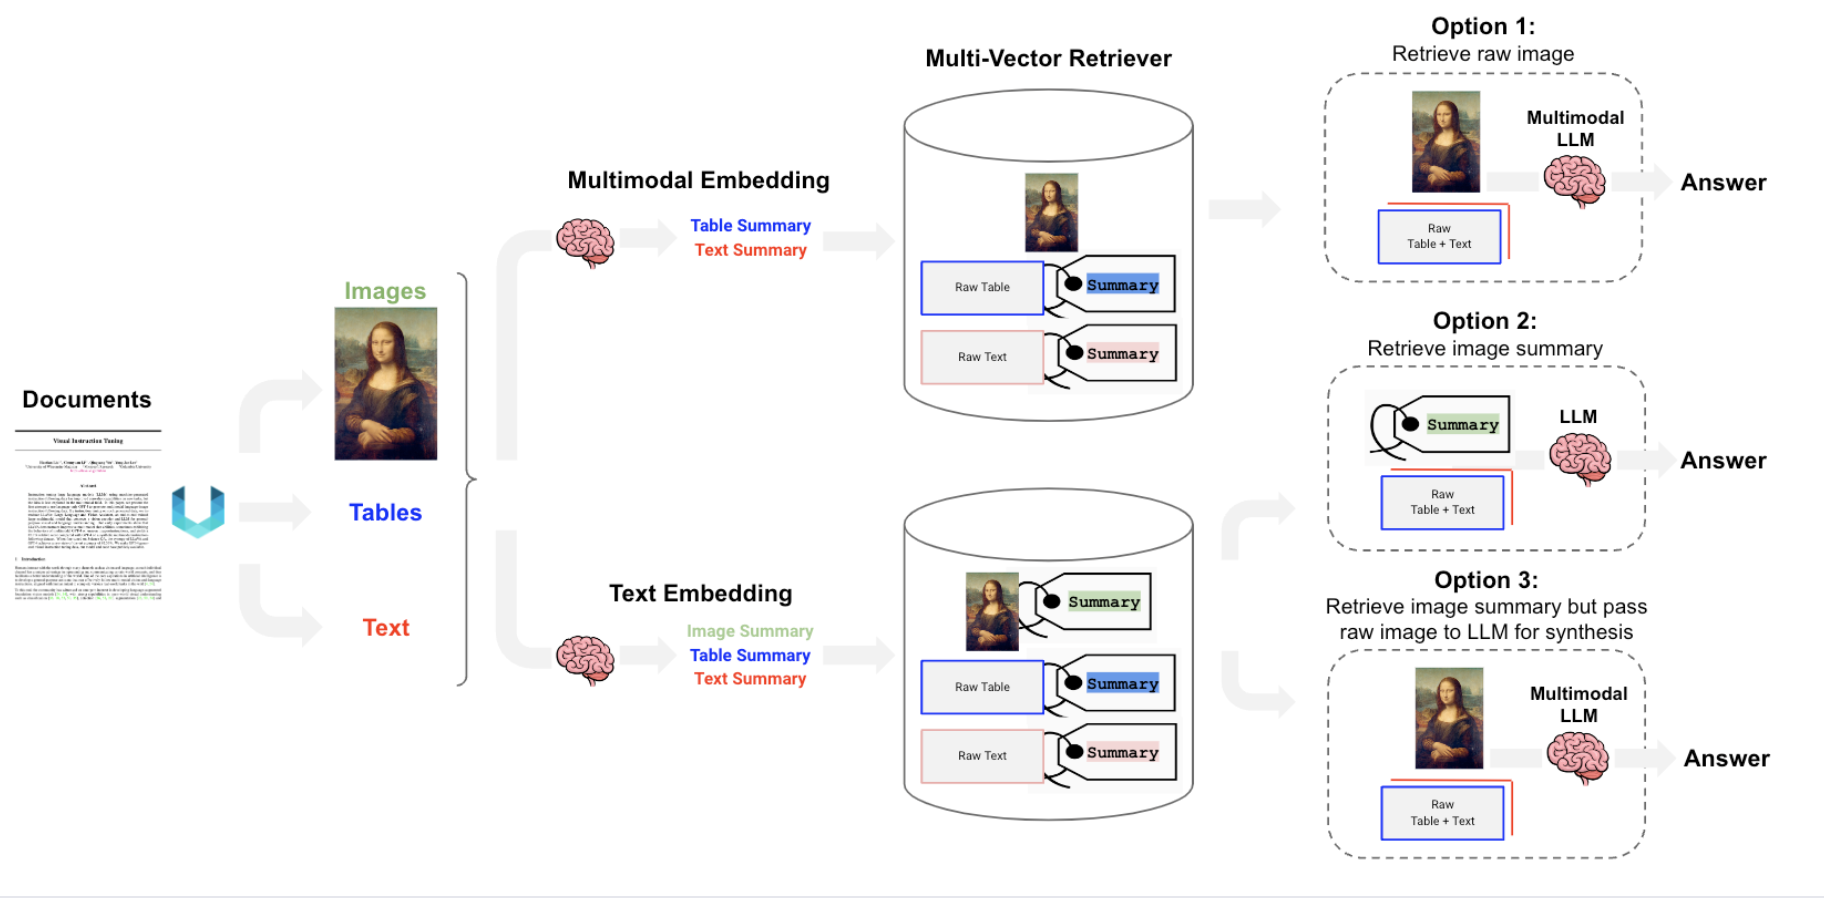

### 1. **요소별 요약(Summary) 생성**

- 텍스트(Text), 표(Table), 이미지(Chart/Figure) 각각에 특화된 요약 체인을 구성합니다.

`(1) 파싱 데이터 분류 및 추출`

In [ ]:
# Docling 결과를 Part2 downstream 변수 시그니처로 매핑
texts = list(parsed["texts"])  # List[str]
tables = [t["markdown"] for t in parsed["tables"] if t.get("markdown")]  # List[str]
images = [i["image_base64"] for i in parsed["images"] if i.get("image_base64")]  # List[base64 str]

print(f"📊 tables(markdown): {len(tables)}개")
print(f"📝 texts: {len(texts)}개")
print(f"🖼️ images(base64): {len(images)}개")


**[결과 해석] 멀티모달 데이터 3-way 분리 구조 (`texts`, `tables`, `images`)**

- **`texts` (본문 텍스트)**: 페이지별 분석 의견, 기업 개요, 산업 전망 텍스트
- **`tables` (구조화 표)**: Markdown 문자열로 변환된 분기별 실적, 재무상태표, 밸류에이션 지표
- **`images` (차트/그림 Base64)**: 주가 추이 차트, 사업부별 매출 비중 파이차트, 증권사 로고 등
→ 세 가지 요소를 독립된 리스트로 분리하여 각 요소의 특성에 최적화된 프롬프트와 LLM 모델을 적용할 수 있도록 준비합니다.


In [ ]:
print(tables[0][:500] if tables else "(empty)")


In [ ]:
print(texts[0][:500] if texts else "(empty)")


In [ ]:
# 이미지 청크 확인
plt_img_base64(images[0])

`(2) 텍스트 및 표 요약 체인 구성`

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# 1. Langfuse 프롬프트 조회 및 객체 보존 (Trace 메타데이터 바인딩용)
fallback_summary_messages = [
    ("system", "당신은 금융 및 비즈니스 문서 요약 전문가입니다. 제공된 텍스트나 표를 분석하여 핵심 정보와 정량 수치를 중심으로 한국어로 간결하게 요약하세요. 불필요한 설명은 생략하세요."),
    ("human", "요약할 내용:\n{element}\n\n요약:")
]
prompt, summary_lf_prompt = get_or_create_langfuse_prompt("financial_summarize_chat_prompt", fallback_summary_messages)

# 2. 요약 체인 생성
model = ChatOpenAI(temperature=0, model="gpt-4.1-mini")
summarize_chain = prompt | model | StrOutputParser()


In [ ]:
# 텍스트 요약 테스트 (Langfuse 트레이싱 + langfuse_prompt 메타데이터 연결)
summary_config = {
    "callbacks": [langfuse_handler],
    "metadata": {
        "langfuse_prompt": summary_lf_prompt,
        "langfuse_tags": ["text-summary-test"]
    }
} if langfuse_handler else {}
text_summary = summarize_chain.invoke(texts[0], config=summary_config)
print(text_summary)


In [ ]:
# 테이블 요약 테스트 (Langfuse 트레이싱 + langfuse_prompt 메타데이터 연결)
summary_config = {
    "callbacks": [langfuse_handler],
    "metadata": {
        "langfuse_prompt": summary_lf_prompt,
        "langfuse_tags": ["table-summary-test"]
    }
} if langfuse_handler else {}
table_summary = summarize_chain.invoke(tables[0], config=summary_config)
print(table_summary)


In [ ]:
# 텍스트 및 테이블 요약 (Langfuse 트레이싱 + langfuse_prompt 메타데이터 적용)
batch_config = {
    "max_concurrency": 3,
    "callbacks": [langfuse_handler] if langfuse_handler else [],
    "metadata": {
        "langfuse_prompt": summary_lf_prompt,
        "langfuse_session_id": "summary-batch-001",
        "langfuse_tags": ["summarization", "docling"],
    }
}

# 텍스트 요약
text_summaries = summarize_chain.batch(texts, config=batch_config)

# 테이블 요약
table_summaries = summarize_chain.batch(tables, config=batch_config)

print(f"Text 요약 개수: {len(text_summaries)}")
print(f"Table 요약 개수: {len(table_summaries)}")


**[결과 해석] 텍스트 및 표 요약 품질 분석**

- **핵심 수치 보존**: 요약 결과를 살펴보면 매출액(2조 6,243억원), 영업이익(1,803억원), 투자의견(BUY), 목표주가(200,000원) 등 **주요 정량 지표가 누락 없이 압축**되어 있습니다.
- **토큰 효율성 향상**: 원본 표 전체(수천 토큰) 대신 핵심 내용만 담긴 요약문(100~200 토큰)을 임베딩함으로써, 검색 벡터의 밀도(Density)를 높여 VectorStore 검색 정확도를 개선합니다.


`(3) 이미지 캡션 및 차트 분석 요약 체인 구성`

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 1. Langfuse 이미지 캡션 프롬프트 연동 (Get-or-Create Chat Prompt)
fallback_image_messages = [
    (
        "system",
        """당신은 멀티모달 시각 데이터 분석 전문가입니다. 제공된 이미지를 면밀히 분석하여 핵심 정보를 상세하게 한국어로 설명하세요.
1. 차트나 그래프: 데이터 트렌드, 축 라벨, 수치, 비교 포인트 기술
2. 다이어그램: 구조, 연결 관계, 프로세스 흐름 기술
3. 표: 주요 데이터 포인트와 패턴 기술
4. 일반 이미지/로고: 주요 객체, 텍스트, 맥락 기술"""
    ),
    (
        "human",
        [
            {"type": "text", "text": "이 이미지를 분석하고 구체적이고 정확하게 설명하세요."},
            {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,{image}"}}
        ]
    )
]

image_prompt, image_lf_prompt = get_or_create_langfuse_prompt("financial_image_summary_chat_prompt", fallback_image_messages)

# 2. 이미지 요약 체인 생성
image_chain = image_prompt | ChatOpenAI(model="gpt-4.1-mini") | StrOutputParser()


In [ ]:
# 이미지 요약 테스트 (Langfuse 트레이싱 + langfuse_prompt 메타데이터 연결)
image_config = {
    "callbacks": [langfuse_handler],
    "metadata": {
        "langfuse_prompt": image_lf_prompt,
        "langfuse_tags": ["image-summary-test"]
    }
} if langfuse_handler else {}

image_summary = image_chain.invoke(images[0], config=image_config)
print(image_summary)


In [ ]:
# 이미지 요약 배치 실행 (Langfuse 트레이싱 + langfuse_prompt 메타데이터 적용)
image_batch_config = {
    "max_concurrency": 3,
    "callbacks": [langfuse_handler] if langfuse_handler else [],
    "metadata": {
        "langfuse_prompt": image_lf_prompt,
        "langfuse_session_id": "image-summary-batch-001",
        "langfuse_tags": ["vision-summary", "docling"],
    }
}
image_summaries = image_chain.batch(images, config=image_batch_config)
print(f"Image 요약 개수: {len(image_summaries)}")


**[결과 해석] 멀티모달 LLM의 시각 차트 요약 역량 분석**

- **비전 분석 결과**: 멀티모달 LLM은 이미지에 포함된 텍스트(예: 회사명, 축 라벨), 차트의 상승/하락 트렌드, 색상 및 레이아웃을 인식해서 자연어로 설명합니다.
- **시각 정보의 텍스트화**: 이미지나 차트 속 시각 정보를 텍스트 요약문으로 변환해 인덱싱하므로, 사용자가 텍스트로 질의할 때도 관련 이미지와 데이터를 효과적으로 검색할 수 있습니다.


In [ ]:
# 추출한 이미지와 요약 결과를 저장할 폴더 경로 (docling 하위로 통일)
output_dir = os.path.join(docling_out_dir, "summaries")
os.makedirs(output_dir, exist_ok=True)

# 요약 결과를 JSON 파일로 저장 (Part3 에서 이 경로를 로드함)
summary_data = {
    "text_summaries": text_summaries,
    "table_summaries": table_summaries,
    "image_summaries": image_summaries
}
with open(os.path.join(output_dir, "summaries.json"), "w", encoding="utf-8") as f:
    json.dump(summary_data, f, ensure_ascii=False, indent=4)
print(f"💾 저장: {os.path.join(output_dir, 'summaries.json')}")


### 2. **MultiVectorRetriever 인덱싱 및 RAG 파이프라인 구성**

`(1) MultiVectorRetriever 구성 (요약은 VectorStore, 원본은 DocStore)`

In [ ]:
from langchain_core.stores import InMemoryStore
import pickle

def save_store_to_disk(store: InMemoryStore, path: str):
    """InMemoryStore를 디스크에 저장"""
    data = dict(store.store)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"💾 Store 저장: {path}")


def load_store_from_disk(path: str):
    """디스크에서 InMemoryStore 로드"""
    with open(path, 'rb') as f:
        data = pickle.load(f)
    new_store = InMemoryStore()
    new_store.store = data
    return new_store

In [ ]:
import uuid

from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

# 자식 청크를 인덱싱하기 위한 벡터 저장소
vectorstore = Chroma(
    collection_name="mm_summaries", 
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",  # 벡터 저장소 경로
)

# 부모 문서를 위한 저장 레이어
store = InMemoryStore()
id_key = "doc_id"

# 검색기 생성 (k=4 명시)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
    search_kwargs={"k": 4},
)


In [ ]:
# retriever.vectorstore.delete_collection()  # 기존 컬렉션 삭제

In [ ]:
### 텍스트 추가 ###

# 각 텍스트에 대한 고유 ID 생성
doc_ids = [str(uuid.uuid4()) for _ in texts]  

# 텍스트 요약 문서 생성 (VectorStore 검색용)
summary_texts = [
    Document(page_content=s, metadata={id_key: doc_ids[i], "source": "text"})
    for i, s in enumerate(text_summaries)
]

# 원본 텍스트 문서 생성 (DocStore 저장용 - Docling 은 문자열 반환)
original_texts = [
    Document(page_content=(t if isinstance(t, str) else getattr(t, "text", str(t))), metadata={id_key: doc_ids[i], "source": "text"})
    for i, t in enumerate(texts)
]

# 벡터 저장소에 텍스트 요약 추가
retriever.vectorstore.add_documents(summary_texts)  

# 문서 저장소에 원본 텍스트 추가
retriever.docstore.mset(list(zip(doc_ids, original_texts)))  

print(f"📄 텍스트 요약 추가: {len(summary_texts)}개")


In [ ]:
# 검색 테스트
query = "삼성전기의 2023년 2분기 매출은 얼마인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata.get("doc_id", "")}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

In [ ]:
### 테이블 요약 추가 ###

# 각 테이블에 대한 고유 ID 생성
table_ids = [str(uuid.uuid4()) for _ in table_summaries]

# 테이블 요약 문서 생성
summary_tables = [
    Document(page_content=s, metadata={id_key: table_ids[i], "source": "table"})
    for i, s in enumerate(table_summaries)
]

# 원본 테이블 문서 생성 (Docling markdown 을 본문으로 저장)
original_tables = [
    Document(page_content=t, metadata={id_key: table_ids[i], "source": "table"})
    for i, t in enumerate(tables)
]

# 벡터 저장소에 테이블 요약 추가
retriever.vectorstore.add_documents(summary_tables)

# 문서 저장소에 원본 테이블 추가
retriever.docstore.mset(list(zip(table_ids, original_tables)))

print(f"📄 테이블 요약 추가: {len(summary_tables)}개")


In [ ]:
# 검색 테스트
query = "삼성전기의 2023년 2분기 매출은 얼마인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata.get("doc_id", "")}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

In [ ]:
### 이미지 요약 추가 ###

# 각 이미지에 대한 고유 ID 생성
img_ids = [str(uuid.uuid4()) for _ in image_summaries]  

# 이미지 요약 문서 생성
summary_images = [
    Document(page_content=s, metadata={id_key: img_ids[i], "source": "image"})
    for i, s in enumerate(image_summaries)
]

# # 벡터 저장소에 이미지 요약 추가
retriever.vectorstore.add_documents(summary_images)  

# 문서 저장소에 이미지 요약 추가
retriever.docstore.mset(list(zip(img_ids, summary_images)))  

print(f"📄 이미지 요약 추가: {len(summary_images)}개")

In [ ]:
# 검색 테스트
query = "삼성전기의 과거 2년간 투자 의견은 무엇인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata.get("doc_id", "")}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

**[결과 해석] MultiVectorRetriever 매핑 및 검색 정확도 분석**

- **검색 작동 원리**: 사용자의 질문(`삼성전기의 과거 2년간 투자 의견은?`)과 가장 유사한 **요약 문서(Child)**를 VectorStore에서 검색한 뒤, 연결된 `doc_id`를 통해 DocStore에서 **원본 텍스트/표/이미지(Parent)**를 즉시 인출합니다.
- **정확도 향상 이유**: 요약문으로 검색하므로 검색 노이즈가 적고, 답변을 생성할 때는 손실 없는 원본 데이터가 컨텍스트로 전달되므로 환각(Hallucination)이 최소화됩니다.


In [ ]:
# store 저장
save_store_to_disk(store, "mm_summaries.pkl")

In [ ]:
# store 로드
loaded_store = load_store_from_disk("mm_summaries.pkl")

# 벡터 저장소 로드
vectorstore = Chroma(
    collection_name="mm_summaries", 
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",  # 벡터 저장소 경로
)

# 로드한 저장소로 새 검색기 만들기
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,  
    docstore=loaded_store,
    id_key=id_key,
)

# 벡터 스토어에서 문서 검색 
docs = retriever.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")
print(f"검색된 문서 개수: {len(docs)}")

In [ ]:
for doc in docs:
    print(f"ID: {doc.metadata.get("doc_id", "")}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

`(2) 텍스트/표 기반 질의응답 RAG 체인 구축`

- `MultiVectorRetriever`가 질의와 관련된 요약을 검색한 뒤 연결된 원본 텍스트 및 표 마크다운을 LLM의 컨텍스트로 제공합니다.
- LLM은 제공된 구조화 표와 텍스트를 바탕으로 정확한 수치와 근거를 포함한 답변을 생성합니다.

In [ ]:
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI

# 1. Langfuse RAG 질의응답 프롬프트 연동 (Get-or-Create Chat Prompt)
fallback_rag_messages = [
    ("system", "Answer the question based only on the following context, which can include text and tables. If the answer cannot be found in the context, state that clearly. Answer in 한국어."),
    ("human", "<Context>\n{context}\n</Context>\n\n<Question>\n{question}\n</Question>")
]
prompt, rag_lf_prompt = get_or_create_langfuse_prompt("financial_rag_chat_prompt", fallback_rag_messages)

# 2. 텍스트 기반 LLM
model = ChatOpenAI(temperature=0, model="gpt-4.1-mini") 

# 3. RAG 파이프라인 구성
chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)


In [ ]:
# chain 실행 (Langfuse 트레이싱 + langfuse_prompt 메타데이터 연결)
rag_config = {
    "callbacks": [langfuse_handler],
    "metadata": {
        "langfuse_prompt": rag_lf_prompt,
        "langfuse_session_id": "qa-demo-01",
        "langfuse_tags": ["rag-eval", "option2", "docling"]
    }
} if langfuse_handler else {}

result = chain.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?", config=rag_config)
print(result)


**[결과 해석] RAG 파이프라인 최종 답변 품질 평가**

- **답변 완성도**: 리포트에 기재된 2024년 예상 매출액(10조 1,212억원) 및 영업이익(8,779억원), 컴포넌트/광학통신/패키지 사업부별 세부 전망이 명확하고 구조화된 문장으로 생성되었습니다.
- **환각 방지 검증**: 프롬프트의 `<Context>`에 주입된 원본 표/텍스트 데이터에 근거해서만 답변하므로, 애널리스트 리포트 원문과 부합하는 신뢰도 높은 응답을 확인할 수 있습니다.


In [ ]:
# chain 실행 (Langfuse 트레이싱 + langfuse_prompt 메타데이터 연결)
rag_config = {
    "callbacks": [langfuse_handler],
    "metadata": {
        "langfuse_prompt": rag_lf_prompt,
        "langfuse_session_id": "qa-demo-02",
        "langfuse_tags": ["rag-eval", "investment-opinion"]
    }
} if langfuse_handler else {}

result = chain.invoke("삼성전기의 과거 2년간 투자 의견은 무엇인가요?", config=rag_config)
print(result)


---

## 🔍 **Langfuse 프롬프트 관리, 트레이싱 및 LLM-as-a-Judge 평가 파이프라인**

프로덕션 RAG 시스템 운영의 핵심 요소인 **(1) 프롬프트 버전 관리, (2) 실행 트레이싱(세션/태그), (3) LLM-as-a-Judge 자동 평가**를 연동합니다.

```mermaid
graph LR
    A[1. Langfuse Prompt Registry<br/>버전 관리 / A-B 테스트] --> B[2. MultiVector RAG Chain<br/>Retriever + LLM 실행]
    B --> C[3. Langfuse Tracing<br/>토큰/지연시간/비용 기록]
    B --> D[4. LLM-as-a-Judge Evaluator<br/>Faithfulness / Relevance / Numerical Accuracy]
    D --> E[5. Langfuse Score<br/>대시보드 피드백 자동 적재]
```


In [ ]:
# 1. Langfuse 프롬프트 버전 관리 및 트레이싱 연동 RAG 실행 함수
import os
from langfuse import get_client
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

def run_rag_with_langfuse(
    query: str, 
    session_id: str = "session-demo-001", 
    user_id: str = "analyst-user-01",
    tags: list = ["part2", "docling", "option2"]
):
    """
    Langfuse 프롬프트 버전 관리(Get or Create) 및 트레이싱 메타데이터가 적용된 RAG 질의응답 실행
    """
    fallback_rag_messages = [
        ("system", "Answer the question based only on the following context, which can include text and structured tables. If not found, state clearly. Answer in 한국어."),
        ("human", "<Context>\n{context}\n</Context>\n\n<Question>\n{question}\n</Question>")
    ]
    prompt_tmpl, lf_prompt = get_or_create_langfuse_prompt("financial_rag_chat_prompt", fallback_rag_messages)

    rag_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt_tmpl
        | model
        | StrOutputParser()
    )
    
    config = {}
    if langfuse_handler:
        config = {
            "callbacks": [langfuse_handler],
            "metadata": {
                "langfuse_prompt": lf_prompt,
                "langfuse_session_id": session_id,
                "langfuse_user_id": user_id,
                "langfuse_tags": tags,
            }
        }
    
    response = rag_chain.invoke(query, config=config)
    
    trace_id = None
    try:
        if langfuse_handler:
            trace_id = get_client().get_current_trace_id()
    except Exception:
        pass
        
    return {
        "query": query,
        "answer": response,
        "trace_id": trace_id
    }

# 실행 테스트
rag_output = run_rag_with_langfuse("삼성전기의 2024년 실적 전망은 어떻게 되나요?")
print("💬 질문:", rag_output["query"])
print("🤖 답변:\n", rag_output["answer"])
print("🔗 Trace ID:", rag_output.get("trace_id", "(Local Mode)"))


In [ ]:
# 2. Pydantic 기반 LLM-as-a-Judge RAG 품질 평가 및 Langfuse Score 자동 기록
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
import os
from langfuse import get_client

# 1. Pydantic 평가 결과 스키마 정의
class RAGEvaluationResult(BaseModel):
    """금융 RAG 시스템 품질 평가 스키마"""
    faithfulness: float = Field(
        ..., ge=0.0, le=1.0, 
        description="답변이 검색 컨텍스트의 사실에만 근거하고 있는지 여부 (0.0~1.0, 환각 없을수록 1.0)"
    )
    answer_relevance: float = Field(
        ..., ge=0.0, le=1.0, 
        description="답변이 사용자의 질문 의도에 직접적으로 부합하는지 여부 (0.0~1.0)"
    )
    numerical_accuracy: float = Field(
        ..., ge=0.0, le=1.0, 
        description="금융 리포트의 수치 데이터(매출, 영업이익, 목표주가 등)가 왜곡 없이 인용되었는지 여부 (0.0~1.0)"
    )
    reasoning: str = Field(
        ..., 
        description="각 지표별 점수 산정 사유를 한국어로 구체적으로 기술"
    )

# 2. Langfuse 평가용 프롬프트 버전 연동 (Get-or-Create Chat Prompt)
fallback_eval_messages = [
    (
        "system", 
        """당신은 금융 RAG 시스템의 신뢰성을 검증하는 전문 평가자(LLM Judge)입니다.
제공된 [질문], [검색 컨텍스트], [생성된 답변]을 바탕으로 아래 3가지 지표를 엄밀히 채점하고 사유를 제시하세요:
1. faithfulness: 컨텍스트 사실 근거 여부 (0.0 ~ 1.0)
2. answer_relevance: 질문 의도 부합 여부 (0.0 ~ 1.0)
3. numerical_accuracy: 재무/수치 데이터 정확성 (0.0 ~ 1.0)"""
    ),
    ("human", "[질문]: {question}\n\n[검색 컨텍스트]:\n{context}\n\n[생성된 답변]:\n{answer}")
]

eval_prompt_template, eval_lf_prompt = get_or_create_langfuse_prompt(
    "financial_rag_eval_judge_prompt", 
    fallback_eval_messages
)

# 3. 구조화된 출력(Structured Output) 평가 체인 생성
judge_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
eval_chain = eval_prompt_template | judge_llm.with_structured_output(RAGEvaluationResult)

def evaluate_and_score_rag(query: str, answer: str, context: str, trace_id: str = None) -> RAGEvaluationResult:
    """
    RAG 결과를 Pydantic Structured Output으로 평가하고 Langfuse 대시보드에 Score 적재
    """
    eval_config = {
        "callbacks": [langfuse_handler],
        "metadata": {
            "langfuse_prompt": eval_lf_prompt,  # 평가 프롬프트 버전 연결
            "langfuse_tags": ["llm-judge", "evaluation"]
        }
    } if langfuse_handler else {}

    # Pydantic 객체로 직접 반환
    eval_result: RAGEvaluationResult = eval_chain.invoke({
        "question": query,
        "context": context,
        "answer": answer
    }, config=eval_config)
    
    # Langfuse 대시보드에 점수 기록
    if trace_id and os.getenv("LANGFUSE_PUBLIC_KEY"):
        try:
            client = get_client()
            metrics = {
                "faithfulness": eval_result.faithfulness,
                "answer_relevance": eval_result.answer_relevance,
                "numerical_accuracy": eval_result.numerical_accuracy
            }
            for name, val in metrics.items():
                client.create_score(
                    trace_id=trace_id,
                    name=name,
                    value=float(val),
                    comment=eval_result.reasoning
                )
            print(f"📊 Langfuse Score 적재 완료 (Trace: {trace_id})")
            client.flush()  # 비동기 점수 즉시 서버 전송
        except Exception as e:
            print(f"ℹ️ Langfuse Score 적재 생략: {e}")
            
    return eval_result

    # 평가 실행 
retrieved_docs = retriever.invoke(rag_output["query"])
context_str = "\n".join([d.page_content for d in retrieved_docs])

eval_report = evaluate_and_score_rag(
    query=rag_output["query"],
    answer=rag_output["answer"],
    context=context_str,
    trace_id=rag_output.get("trace_id")
)

print("\n🏆 [LLM-as-a-Judge Pydantic 평가 결과 리포트]")
print(f"  • Faithfulness (근거 충실도): {eval_report.faithfulness}")
print(f"  • Answer Relevance (질문 관련성): {eval_report.answer_relevance}")
print(f"  • Numerical Accuracy (수치 정확도): {eval_report.numerical_accuracy}")
print(f"  • 평가 사유: {eval_report.reasoning}")


---
## **[실습 1] LangGraph 기반 페이지 출처(Citation) 보존 멀티모달 RAG 그래프 구축**

- 문서명(`doc_name`)과 `page_number` 메타데이터를 LangGraph `State`로 체계적으로 관리하고, 검색된 컨텍스트 및 인용 출처(문서명과 페이지 번호)를 명시하여 답변을 생성하는 상태 기반 RAG 워크플로우를 구현합니다.

```mermaid
graph LR
    StartNode["START"] --> Retrieve["1. retrieve<br/>MultiVectorRetriever 검색"]
    Retrieve --> Format["2. format_context<br/>출처 메타데이터 바인딩"]
    Format --> Generate["3. generate<br/>출처 인용 답변 생성"]
    Generate --> EndNode["END"]
```

In [ ]:
# 여기에 코드를 작성하세요.

---
## **[실습 2] Adaptive RAG + CRAG + Self-RAG 결합 멀티모달 Agentic RAG 그래프 구축**

앞서 구축한 멀티모달 문서 벡터스토어(`retriever`)를 기반으로 **Adaptive Routing**, **CRAG(문서 평가 및 쿼리 교정)**, **Self-RAG(할루시네이션 및 출처 부합성 자가 검증)** 패턴을 결합하여 고신뢰성 금융 Agentic RAG 그래프를 완성합니다.

```mermaid
graph TD
    StartNode["START"] --> Router{"1. route_question<br/>질문 유형 판별"}
    
    Router -->|일반 금융 상식| DirectLLM["direct_answer<br/>LLM 직접 응답"]
    Router -->|사내 리포트 질의| Retrieve["2. retrieve<br/>MultiVectorRetriever 검색"]
    
    Retrieve --> GradeDocs["3. grade_documents<br/>CRAG 적합성 평가"]
    
    GradeDocs --> Decision{"4. decide_to_generate<br/>적합 문서 유무"}
    Decision -->|적합 문서 확보| Generate["5. generate<br/>출처 인용 답변 생성"]
    Decision -->|적합 문서 부족| Rewrite["6. rewrite_query<br/>검색 쿼리 교정"]
    Rewrite --> Retrieve
    
    Generate --> CheckHallucination{"7. check_groundedness<br/>Self-RAG 할루시네이션 검증"}
    CheckHallucination -->|근거 부합| EndNode["END"]
    CheckHallucination -->|근거 불일치 재시도| Generate
    DirectLLM --> EndNode
```

In [ ]:
# 여기에 코드를 작성하세요.